In [54]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
file_path = "/content/drive/MyDrive/Colab notebooks/Data/ICU_filtered.csv"  # Specify the file path
dataset = pd.read_csv(file_path)

In [55]:
# Filter data to include only samples where "In-hospital_death" is equal to 1 for training
train_dataset = dataset[dataset["In-hospital_death"] == 1]

# Preprocessing steps for training data (replace this with your preprocessing code)
# Impute missing values
imputer = SimpleImputer(strategy='mean')  # Use mean imputation for missing values
X_train_imputed = imputer.fit_transform(train_dataset.drop(columns=["In-hospital_death"]))
y_train = train_dataset["In-hospital_death"]

# Normalize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Preprocessing steps for test data (replace this with your preprocessing code)
X_test_imputed = imputer.transform(dataset.drop(columns=["In-hospital_death"]))
y_test = dataset["In-hospital_death"]

# Normalize the features
X_test_scaled = scaler.transform(X_test_imputed)


In [56]:
## Parameters for the autoencoder
batch_size = 256
max_epochs = 50
learning_rate = 1e-03
latent_dim = 128
hidden_dim = 256
original_dim = X_train_scaled.shape[1]

In [57]:
training_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test)).batch(batch_size)


In [58]:
## Encoder
class Encoder(tf.keras.layers.Layer):
  # Define input independent model information
  def __init__(self, hidden_dim, latent_dim):
    super(Encoder, self).__init__()
    self.encoder_layer1 = tf.keras.layers.Dense(units = hidden_dim, activation = tf.nn.relu)
    self.encoder_layer2 = tf.keras.layers.Dense(units = latent_dim, activation = tf.nn.relu)

  ## Method for forward propagation
  def call(self, input_features):
    a = self.encoder_layer1(input_features)
    a = self.encoder_layer2(a)
    return a

In [59]:
## Decoder
class Decoder(tf.keras.layers.Layer):
  def __init__(self, latent_dim, hidden_dim, original_dim):
    super(Decoder, self).__init__()
    self.decoder_layer1 = tf.keras.layers.Dense(units = hidden_dim, activation = tf.nn.relu)
    self.decoder_layer2 = tf.keras.layers.Dense(units = original_dim, activation = tf.nn.relu)

  def call(self, encoded_features):
    a = self.decoder_layer1(encoded_features)
    a = self.decoder_layer2(a)
    return a


In [60]:
## Autoencoder
class Autoencoder(tf.keras.Model):
  def __init__(self, latent_dim, hidden_dim, original_dim):
    super(Autoencoder, self).__init__()
    self.loss = []
    self.encoder = Encoder(hidden_dim = hidden_dim, latent_dim = latent_dim)
    self.decoder = Decoder(latent_dim = latent_dim, hidden_dim = hidden_dim, original_dim = original_dim)

  def call(self, input_features):
    encoded_features = self.encoder(input_features)
    reconstructed_features = self.decoder(encoded_features)
    return reconstructed_features

In [61]:
## Build model
autoencoder = Autoencoder(latent_dim = latent_dim,
                          hidden_dim = hidden_dim,
                          original_dim = original_dim)

In [62]:
## Optimizer
opt = tf.keras.optimizers.Adam(learning_rate = learning_rate)

In [63]:
## Custom training - loss
def loss(true, pred):
  return tf.reduce_mean(tf.square(tf.subtract(true, pred)))

## Custom training - compute gradient of loss and update weights
@tf.function
def train(model, loss, opt, original_features, labels):
  with tf.GradientTape() as g:
    pred = tf.cast(model(original_features), tf.float64)
    loss_batch = loss(original_features, pred)
  gradients = g.gradient(loss_batch, model.trainable_variables)
  opt.apply_gradients(zip(gradients, model.trainable_variables))
  return loss_batch

Epoch 1, loss = 0.9958738088607788
Epoch 2, loss = 0.9582988023757935
Epoch 3, loss = 0.9199066162109375
Epoch 4, loss = 0.883094310760498
Epoch 5, loss = 0.8475739359855652
Epoch 6, loss = 0.8141357898712158
Epoch 7, loss = 0.783517599105835
Epoch 8, loss = 0.7565585970878601
Epoch 9, loss = 0.7330167889595032
Epoch 10, loss = 0.7123885154724121
Epoch 11, loss = 0.6941137909889221
Epoch 12, loss = 0.6777874827384949
Epoch 13, loss = 0.6632906198501587
Epoch 14, loss = 0.650378406047821
Epoch 15, loss = 0.6388600468635559
Epoch 16, loss = 0.6284408569335938
Epoch 17, loss = 0.6190235018730164
Epoch 18, loss = 0.6104958653450012
Epoch 19, loss = 0.6026972532272339
Epoch 20, loss = 0.5955796837806702
Epoch 21, loss = 0.5890616178512573
Epoch 22, loss = 0.5830549597740173
Epoch 23, loss = 0.5775271654129028
Epoch 24, loss = 0.5724314451217651
Epoch 25, loss = 0.5677126049995422
Epoch 26, loss = 0.5633397102355957
Epoch 27, loss = 0.5592898726463318
Epoch 28, loss = 0.5555149912834167
Epoc

Text(0.5, 1.0, 'Loss vs. Epoch')

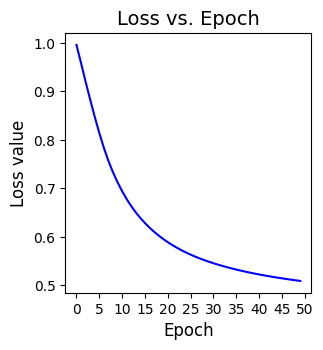

In [64]:
## Train network
# Variable to store training loss per epoch
loss_train_epoch = tf.keras.metrics.Mean()
loss_train_epoch_plot = np.empty(max_epochs)

# Iterate over epochs
for epoch in range(max_epochs):
  for step, (train_batch_features, train_batch_labels) in enumerate(training_dataset):
    loss_batch = train(autoencoder, loss, opt, train_batch_features, train_batch_labels)
    # Append training loss
    loss_train_epoch(loss_batch)
  loss_train_epoch_plot[epoch] = loss_train_epoch.result().numpy()
  print(f'Epoch {epoch+1}, loss = {loss_train_epoch_plot[epoch]}')

# Plot train loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(loss_train_epoch_plot, 'b')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.set_xticks(np.arange(0, max_epochs+1, 5))
ax.set_title('Loss vs. Epoch', fontsize = 14)

247/247 [==============================] - 2s 5ms/step


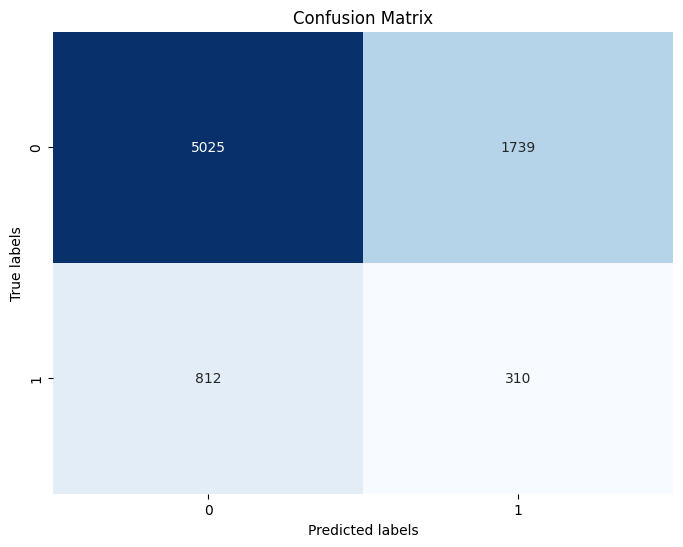

In [65]:
# Calculate reconstruction errors on test data
reconstructions = autoencoder.predict(X_test_scaled)
mse = np.mean(np.square(X_test_scaled - reconstructions), axis=1)

# Define a threshold for classification
threshold = 0.5  # You can adjust this threshold as per your requirement

# Classify instances based on reconstruction error
y_pred = np.where(mse > threshold, 1, 0)

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.show()

# Flatten true labels
y_test_flat = y_test.values.flatten()

# Plot confusion matrix
plot_confusion_matrix(y_test_flat, y_pred)